In [38]:
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

import os
import sys

sys.path.append(os.path.abspath(".."))

folder = '/Volumes/My Passport/Sasaki/MTsingleBeads'

track_path = 'MTtrack.csv'

path0 = os.path.join(folder, "20260121/beads_trans_crop_crop", track_path)
path1 = os.path.join(folder, "20260121/exp_crop1", track_path)
path2 = os.path.join(folder, "20260122/exp", track_path)
path3 = os.path.join(folder, "20260122/exp001", track_path)

def vec(df):
    # 1. 前処理: frameでソートしておく（groupby内での処理を減らすため）
    df = df.sort_values(['particle', 'frame'])

    # 2. 差分計算（各グループの最初の一行はNaNになる）
    # diff() は pandas のメソッドを使うとインデックスが維持されるので安全です
    dx = df.groupby('particle')['x'].diff()
    dy = df.groupby('particle')['y'].diff()

    # 3. 速度ベクトルと単位ベクトルの計算
    v = np.sqrt(dx**2 + dy**2)

    df['theta'] = dx/v + 1j * dy/v

    return df

def calculate_polar_order(df):
    """
    各フレームごとのポーラー度（Order Parameter）を算出する
    """
    # 1. 各フレームごとに複素ベクトルの平均を取る
    # thetaには既に単位ベクトル（dx/v + i*dy/v）が入っている前提
    group_avg = df.groupby('frame')['theta'].mean()
    
    # 2. 平均ベクトルの絶対値（長さ）を計算する
    # これが 1 に近いほど揃っており、0 に近いほどバラバラ
    polar_order = group_avg.abs()
    
    return polar_order

paths = [path0, path1, path2, path3]
labels = ['exp_0', 'exp_1', 'exp_2', 'exp_3'] # 任意のラベル

polars_dict = {}

for path, label in zip(paths, labels):
    df_temp = pd.read_csv(path)
    df_temp = vec(df_temp)
    # calculate_polar_order の結果を辞書に格納
    polars_dict[label] = calculate_polar_order(df_temp)

# 辞書から一気にDataFrameを作成（frameがインデックスになります）
df_polar_all = pd.DataFrame(polars_dict)

print(df_polar_all.head())

          exp_0     exp_1     exp_2     exp_3
frame                                        
0           NaN       NaN       NaN       NaN
1      0.599807  0.422527  0.114960  0.288503
2      0.998038  0.545340  0.195914  0.227181
3      0.997901  0.498173  0.160361  0.184195
4      0.775135  0.495311  0.100970  0.147998


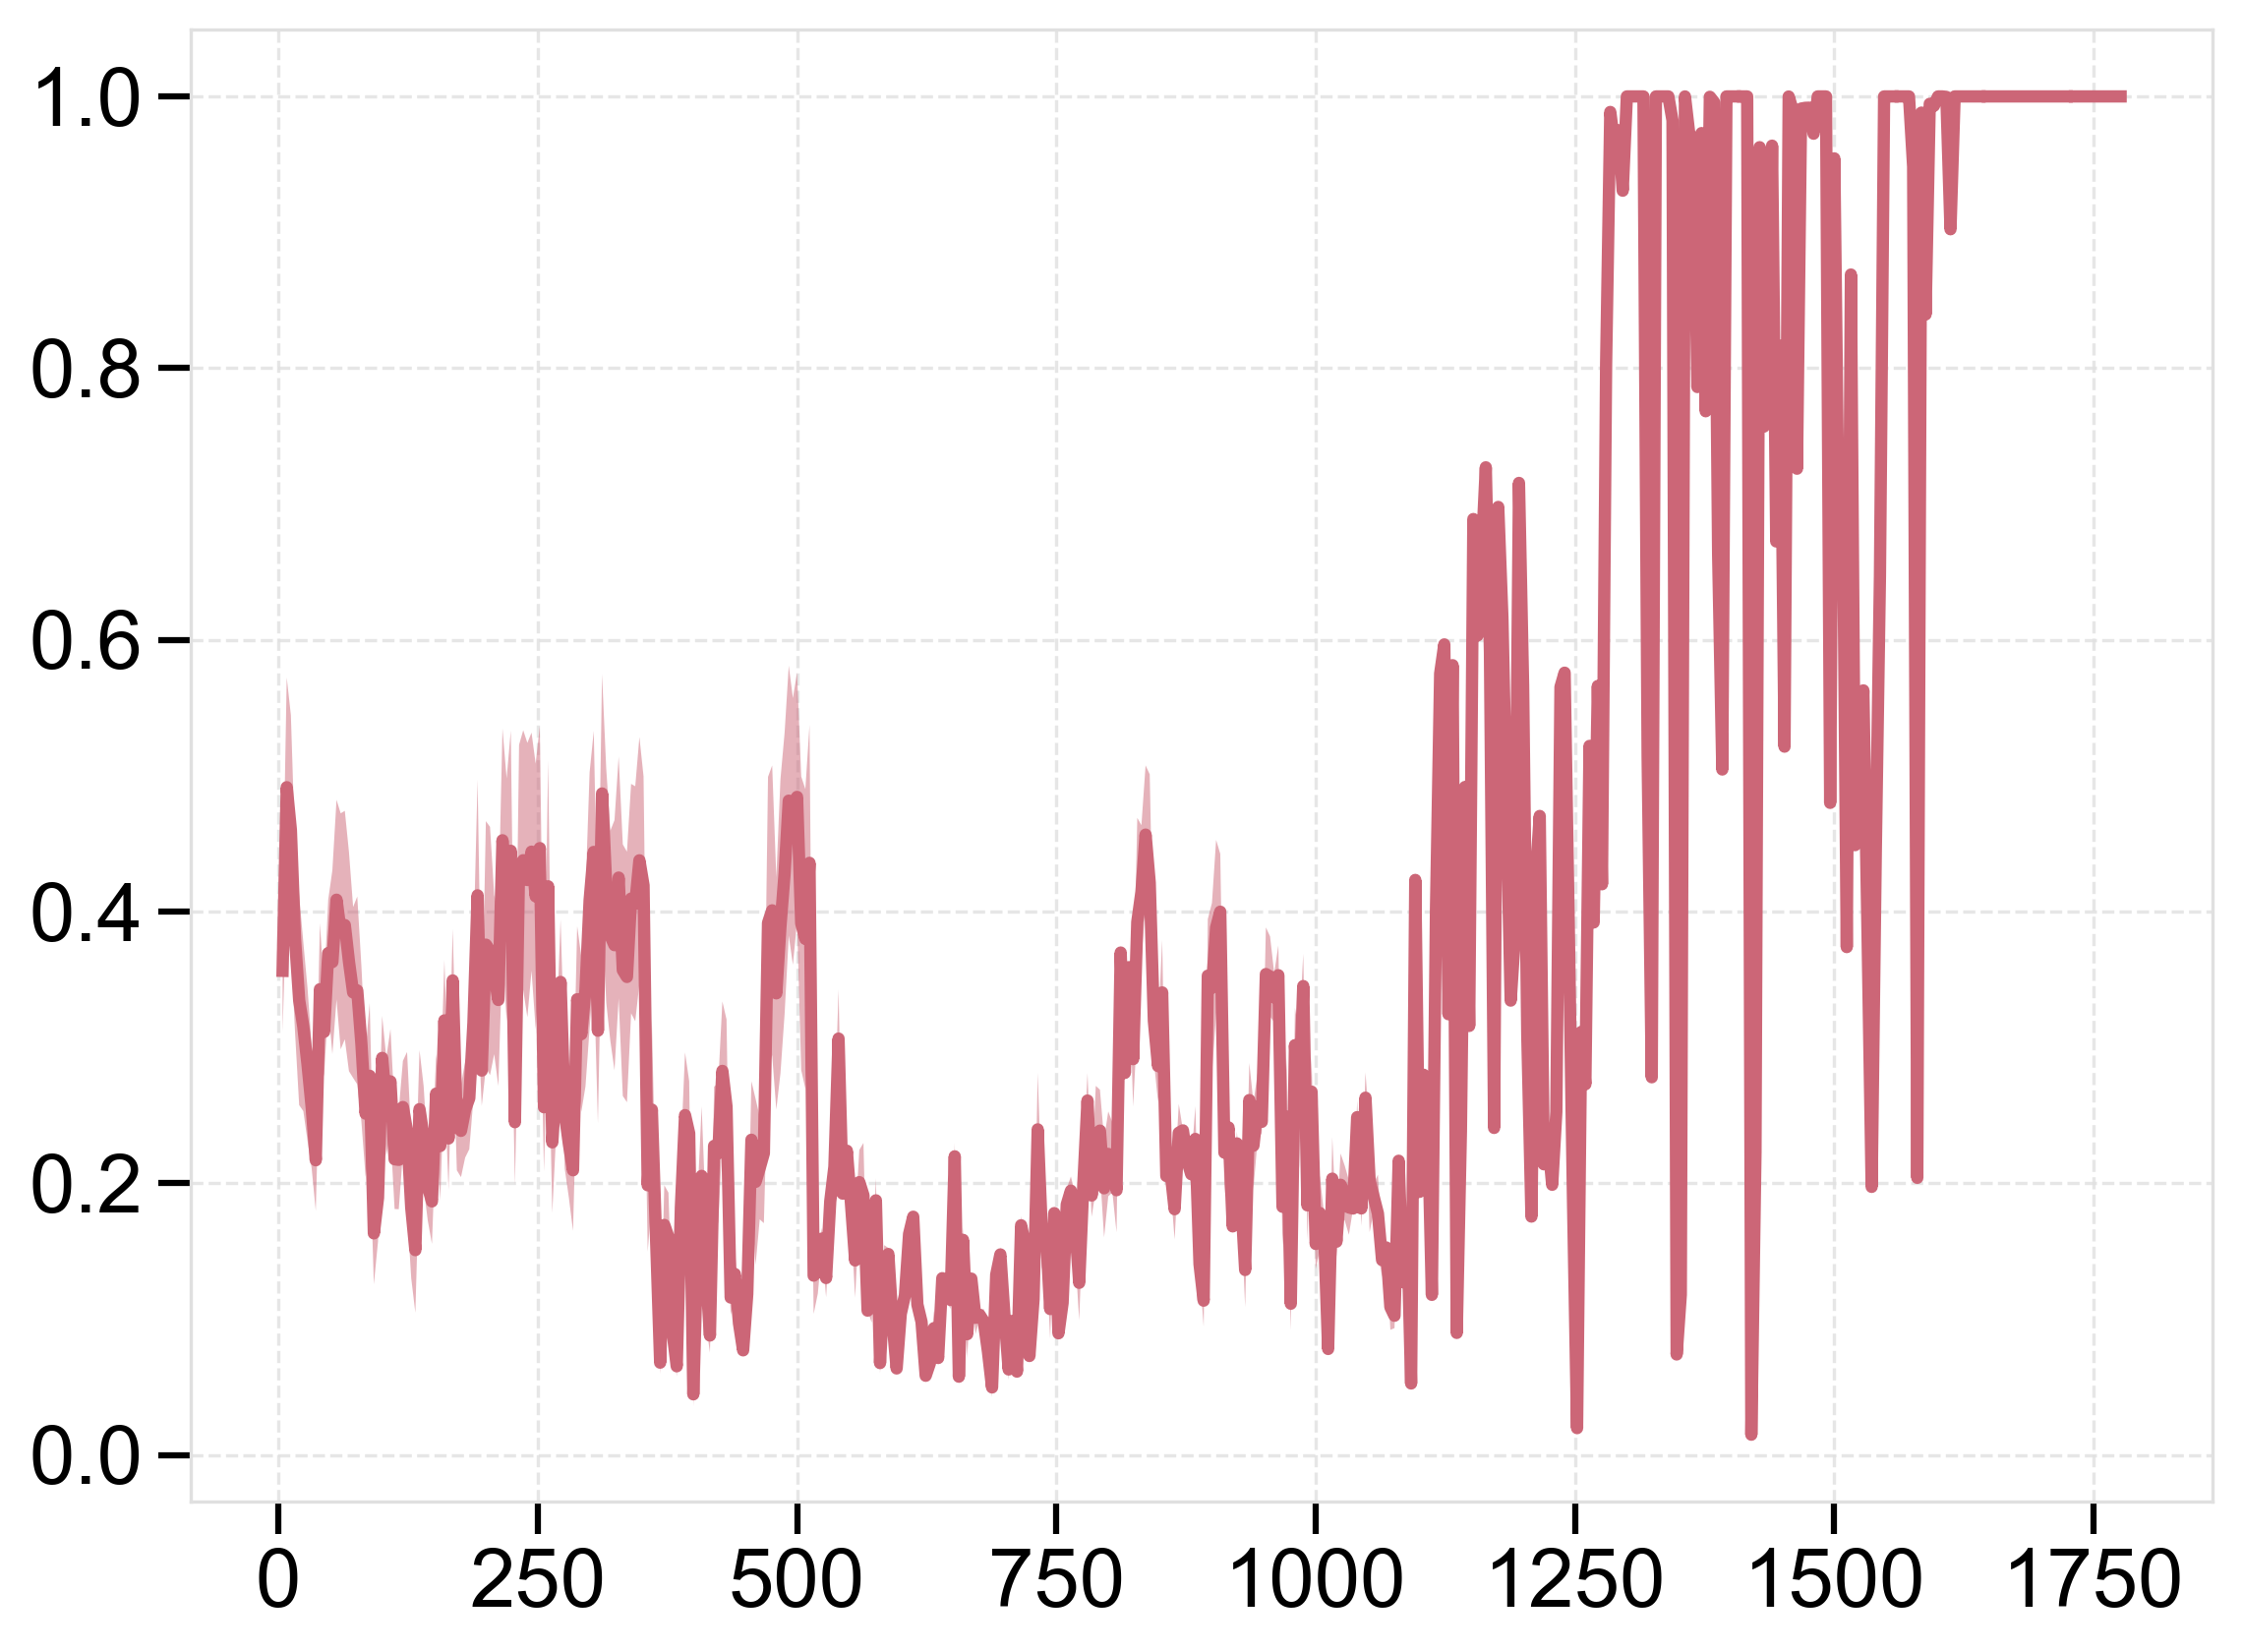

In [46]:
mean = np.mean(df_polar_all, axis = 1)
sem = np.std(df_polar_all, axis = 1)/4

fig, ax = plt.subplots()

ax.plot(np.arange(len(mean)) * 4, mean)
ax.fill_between(np.arange(len(mean)) * 4, mean - sem, mean + sem, alpha = 0.5)

In [43]:
np.mean(df_polar_all, axis = 1)

frame
0           NaN
1      0.356449
2      0.491618
3      0.460157
4      0.379853
         ...   
465    1.000000
466    1.000000
467    1.000000
468    1.000000
469    1.000000
Length: 445, dtype: float64